In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

In [ ]:
PARQUET_PATH = '../data/chicago_taxi_2024_2026_clean.parquet'

print(f'Loading: {PARQUET_PATH}')
df_2025_clean = pd.read_parquet(PARQUET_PATH)
print(f'Loaded {len(df_2025_clean):,} rows and {df_2025_clean.shape[1]} columns.')
df_2025_clean.head(10)

Loading: ../data/chicago_taxi_2025_clean.parquet
Loaded 5,652,351 rows and 25 columns.


,trip_id,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,...,payment_type,company,pickup_centroid_latitude,pickup_centroid_longitude,dropoff_centroid_latitude,dropoff_centroid_longitude,pickup_ca_centroid_lat,pickup_ca_centroid_lon,dropoff_ca_centroid_lat,dropoff_ca_centroid_lon
0,0826d395e39c5ea146c37c8a78a03c012986b167,b89de8fefce2927a1bbc747ac861743fc5482ed36590d2...,2025-01-07 23:45:00,2025-01-08 00:00:00,1405.0,14.84,NaN,NaN,76,6,...,Credit Card,Taxicab Insurance Agency Llc,41.980264,-87.913625,41.944227,-87.655998,41.980264,-87.913625,41.944227,-87.655998
1,f7249eff1aad5ea1b3d53539a4003f3348786b27,60d596d3448473e61c35fc30a37bf8fda28d4ae7fa3bea...,2025-01-07 23:45:00,2025-01-08 00:00:00,318.0,1.30,NaN,NaN,8,8,...,Cash,Flash Cab,41.899602,-87.633308,41.899602,-87.633308,41.899602,-87.633308,41.899602,-87.633308
2,e7f005ad347a0f7f699523fc7843ba5f8b8792c1,0b0be23bf69b80dd81715f86c4e0887bbd5d9ebc2463b8...,2025-01-07 23:45:00,2025-01-07 23:45:00,419.0,0.87,NaN,NaN,8,8,...,Credit Card,Blue Ribbon Taxi Association,41.899602,-87.633308,41.899602,-87.633308,41.899602,-87.633308,41.899602,-87.633308
3,e6df7890fb2d74e09132af5cde612ea36ff5360d,488f74778b200fa256453e785aceb902249139d4880bc1...,2025-01-07 23:45:00,2025-01-08 00:00:00,1272.0,14.37,NaN,NaN,76,22,...,Credit Card,Chicago Taxicab,41.980264,-87.913625,41.922761,-87.699155,41.980264,-87.913625,41.922761,-87.699155
4,d5f005f6e423e808546dd1419fee4f2dafc55872,b9a58663518c48b09e83f462ca25ee0d702a2e4bc12199...,2025-01-07 23:45:00,2025-01-08 00:00:00,1368.0,17.25,NaN,NaN,76,28,...,Credit Card,City Service,41.980264,-87.913625,41.874005,-87.663518,41.980264,-87.913625,41.874005,-87.663518
5,c975968710f4e8570e31a68b84db2b4e3f5613a0,c60633c5d2053dd1c2076286b88196cf83f4fe0ecc1945...,2025-01-07 23:45:00,2025-01-07 23:45:00,719.0,11.78,NaN,NaN,40,54,...,Prcard,Chicago Independents,41.792357,-87.617931,41.660136,-87.602848,41.792357,-87.617931,41.660136,-87.602848
6,bbd2755710891b818924f1d07510738e9032333c,6dd401969a491b3ea0d09788d990afdd053435e2ca9ee0...,2025-01-07 23:45:00,2025-01-08 00:00:00,1211.0,14.58,NaN,NaN,76,7,...,Credit Card,Taxicab Insurance Agency Llc,41.980264,-87.913625,41.922686,-87.649489,41.980264,-87.913625,41.922686,-87.649489
7,b6e0f36f94e08286fe9e104a85a7c0f195470d74,02ef8f01232b1b1828f4e5e1b8e8a85cd71b67c449afaf...,2025-01-07 23:45:00,2025-01-08 00:00:00,1148.0,10.87,NaN,NaN,8,68,...,Prcard,City Service,41.899602,-87.633308,41.777196,-87.642498,41.899602,-87.633308,41.777196,-87.642498
8,a6e57c6d1db2505002931da283a383f4d3338fcf,3835dded237bfc6b12d2181ec37148bd8385590f81597f...,2025-01-07 23:45:00,2025-01-08 00:00:00,711.0,5.61,NaN,NaN,8,6,...,Credit Card,Blue Ribbon Taxi Association,41.899602,-87.633308,41.944227,-87.655998,41.899602,-87.633308,41.944227,-87.655998
9,a30da51b4e78dc2b77d4bce408a4d76e9834a565,cf676de36353be7581fc132e7b707e919d1541b82e2d97...,2025-01-07 23:45:00,2025-01-08 00:00:00,960.0,11.10,NaN,NaN,3,36,...,Unknown,Taxi Affiliation Services,41.965812,-87.655879,41.823713,-87.602350,41.965812,-87.655879,41.823713,-87.602350


In [ ]:
sample_data_df = df_2025_clean.sample(
    n=100_000,
    random_state=42
)

In [ ]:
sample_data_df["trip_start_timestamp"] = pd.to_datetime(
    sample_data_df["trip_start_timestamp"]
)

sample_data_df["trip_end_timestamp"] = pd.to_datetime(
    sample_data_df["trip_end_timestamp"]
)


In [ ]:
metrics = {
    "Number of trips": sample_data_df["trip_id"].count(),
    "Average trip duration (seconds)": sample_data_df["trip_seconds"].mean(),
    "Average fare per trip": sample_data_df["trip_total"].mean(),
    "Fare per minute": sample_data_df["trip_total"].sum() / (sample_data_df["trip_seconds"].sum() / 60),
    "Total revenue": sample_data_df["trip_total"].sum(),
    "Tips per trip": sample_data_df["tips"].mean(),
    "Average trip distance (miles)": sample_data_df["trip_miles"].mean()
}

metrics_df = pd.DataFrame(metrics.items(), columns=["metric", "value"])
metrics_df

,metric,value
0,Number of trips,1.000000e+05
1,Average trip duration (seconds),1.206382e+03
2,Average fare per trip,2.428554e+01
3,Fare per minute,1.207853e+00
4,Total revenue,2.428554e+06
5,Tips per trip,2.462680e+00
6,Average trip distance (miles),6.445750e+00


In [ ]:
df_plot = sample_data_df.copy()

df_plot["trip_minutes"] = df_plot["trip_seconds"] / 60
df_plot["fare_per_minute"] = df_plot["trip_total"] / df_plot["trip_minutes"]

# Optional: remove invalid / extreme values for cleaner plots
df_plot = df_plot[
    (df_plot["trip_seconds"] > 0) &
    (df_plot["trip_total"] >= 0) &
    (df_plot["tips"] >= 0)
].copy()

df_plot = df_plot.replace([float("inf"), -float("inf")], pd.NA)

In [ ]:
# Make sure timestamps are datetime
df_plot["trip_start_timestamp"] = pd.to_datetime(df_plot["trip_start_timestamp"])
df_plot["trip_end_timestamp"] = pd.to_datetime(df_plot["trip_end_timestamp"])

# Sort by taxi and start time so "next trip" is meaningful
df_plot = df_plot.sort_values(["taxi_id", "trip_start_timestamp"]).copy()

# Next trip start for the same taxi
df_plot["next_trip_start"] = (
    df_plot
    .groupby("taxi_id")["trip_start_timestamp"]
    .shift(-1)
)

# Idle time between this trip ending and the next trip starting
df_plot["idle_time_seconds"] = (
    df_plot["next_trip_start"] - df_plot["trip_end_timestamp"]
).dt.total_seconds()

# Optional cleaning: remove impossible negative idle times
df_plot.loc[df_plot["idle_time_seconds"] < 0, "idle_time_seconds"] = pd.NA

df_plot["idle_time_minutes"] = df_plot["idle_time_seconds"] / 60

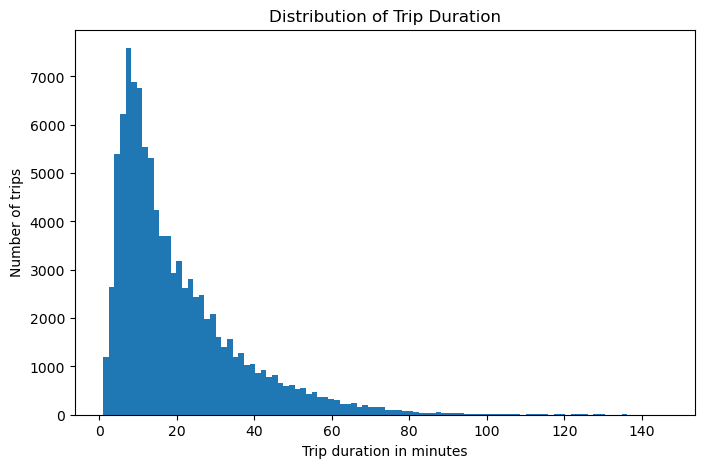

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df_plot["trip_minutes"].dropna(), bins=100)
plt.title("Distribution of Trip Duration")
plt.xlabel("Trip duration in minutes")
plt.ylabel("Number of trips")
plt.show()

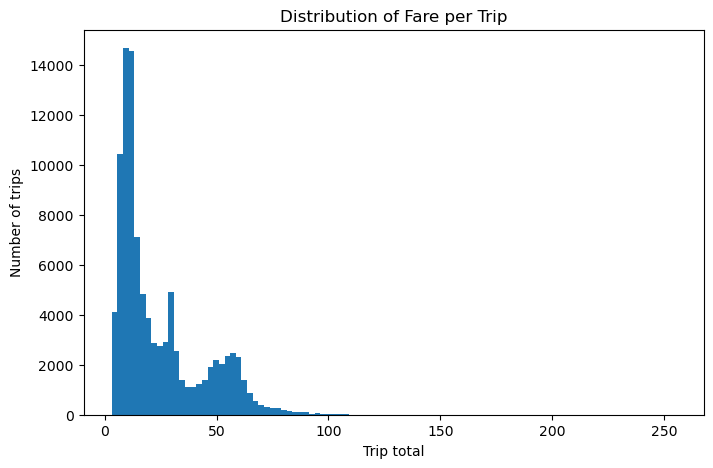

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df_plot["trip_total"].dropna(), bins=100)
plt.title("Distribution of Fare per Trip")
plt.xlabel("Trip total")
plt.ylabel("Number of trips")
plt.show()

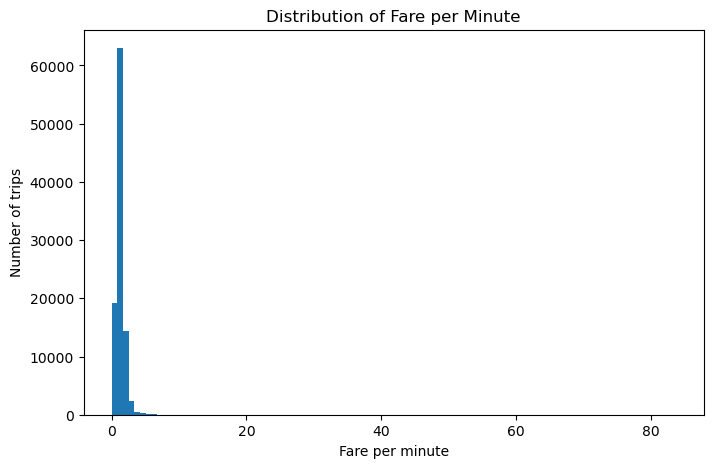

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df_plot["fare_per_minute"].dropna(), bins=100)
plt.title("Distribution of Fare per Minute")
plt.xlabel("Fare per minute")
plt.ylabel("Number of trips")
plt.show()

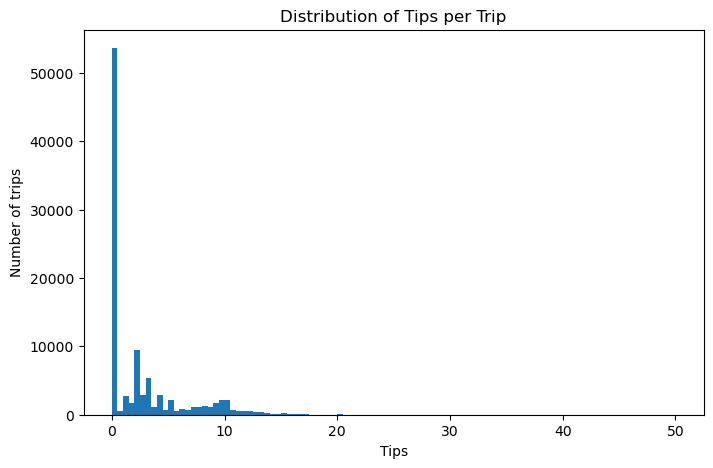

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df_plot["tips"].dropna(), bins=100)
plt.title("Distribution of Tips per Trip")
plt.xlabel("Tips")
plt.ylabel("Number of trips")
plt.show()

In [ ]:
df_plot["date"] = df_plot["trip_start_timestamp"].dt.date

daily_metrics = (
    df_plot
    .groupby("date")
    .agg(
        number_of_trips=("trip_id", "count"),
        average_trip_duration_seconds=("trip_seconds", "mean"),
        average_fare_per_trip=("trip_total", "mean"),
        total_revenue=("trip_total", "sum"),
        tips_per_trip=("tips", "mean"),
        total_trip_seconds=("trip_seconds", "sum"),
        average_trip_distance_miles=("trip_miles", "mean")
    )
)

daily_metrics["fare_per_minute"] = (
    daily_metrics["total_revenue"] / (daily_metrics["total_trip_seconds"] / 60)
)

daily_metrics.head()

,number_of_trips,average_trip_duration_seconds,average_fare_per_trip,total_revenue,tips_per_trip,total_trip_seconds,average_trip_distance_miles,fare_per_minute
date,,,,,,,,
2025-01-01,143,991.937063,24.459650,3497.73,2.192727,141847.0,6.747343,1.479508
2025-01-02,159,1131.955975,24.518805,3898.49,2.188553,179981.0,6.909308,1.299634
2025-01-03,156,1052.814103,23.336090,3640.43,2.072756,164239.0,6.518654,1.329927
2025-01-04,139,1119.395683,26.098345,3627.67,2.314676,155596.0,7.505468,1.398880
2025-01-05,125,1223.352000,34.194160,4274.27,3.177600,152919.0,10.573040,1.677072


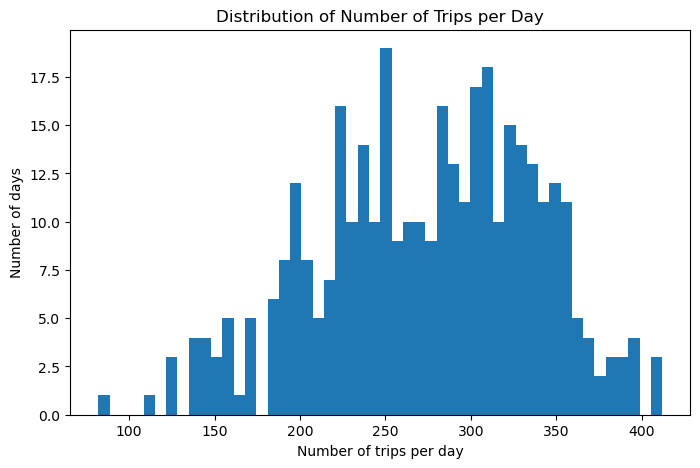

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(daily_metrics["number_of_trips"].dropna(), bins=50)
plt.title("Distribution of Number of Trips per Day")
plt.xlabel("Number of trips per day")
plt.ylabel("Number of days")
plt.show()

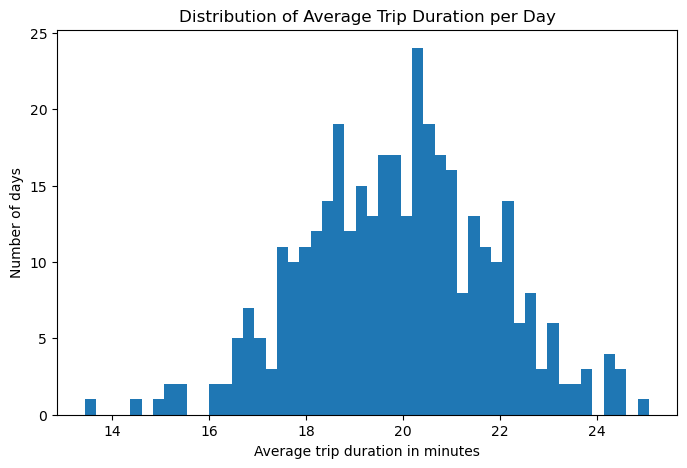

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(daily_metrics["average_trip_duration_seconds"].dropna() / 60, bins=50)
plt.title("Distribution of Average Trip Duration per Day")
plt.xlabel("Average trip duration in minutes")
plt.ylabel("Number of days")
plt.show()

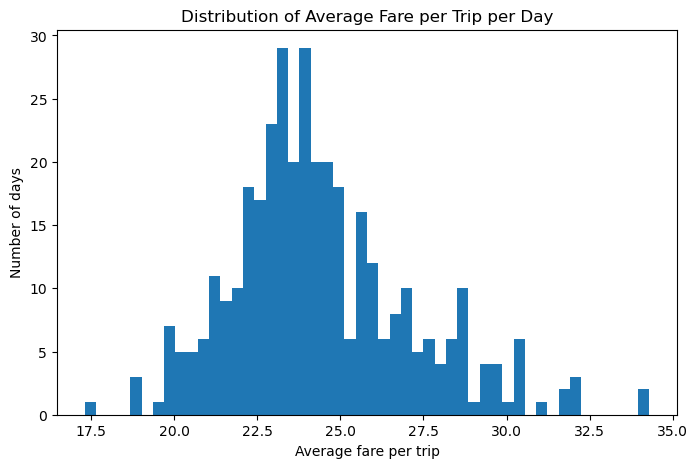

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(daily_metrics["average_fare_per_trip"].dropna(), bins=50)
plt.title("Distribution of Average Fare per Trip per Day")
plt.xlabel("Average fare per trip")
plt.ylabel("Number of days")
plt.show()

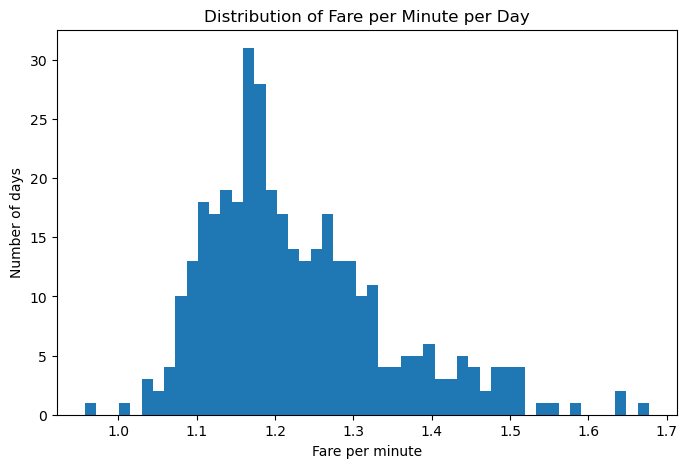

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(daily_metrics["fare_per_minute"].dropna(), bins=50)
plt.title("Distribution of Fare per Minute per Day")
plt.xlabel("Fare per minute")
plt.ylabel("Number of days")
plt.show()

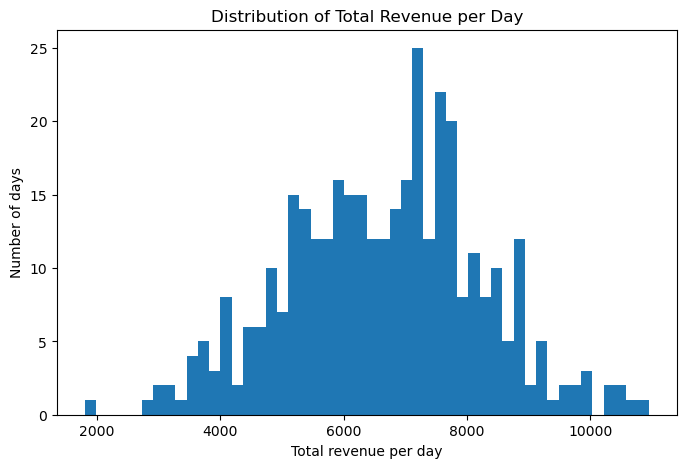

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(daily_metrics["total_revenue"].dropna(), bins=50)
plt.title("Distribution of Total Revenue per Day")
plt.xlabel("Total revenue per day")
plt.ylabel("Number of days")
plt.show()

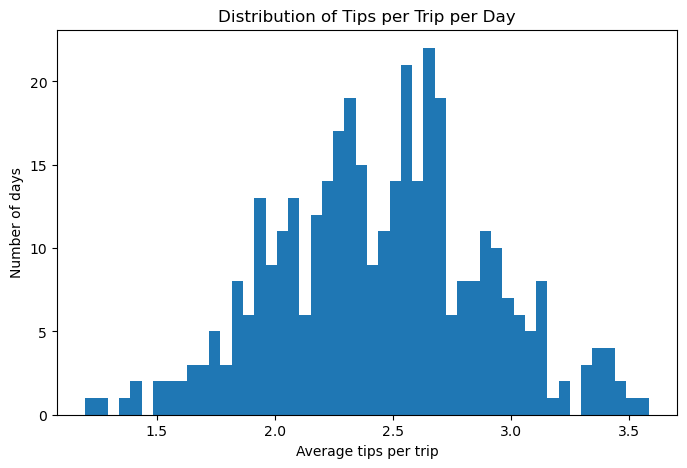

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(daily_metrics["tips_per_trip"].dropna(), bins=50)
plt.title("Distribution of Tips per Trip per Day")
plt.xlabel("Average tips per trip")
plt.ylabel("Number of days")
plt.show()

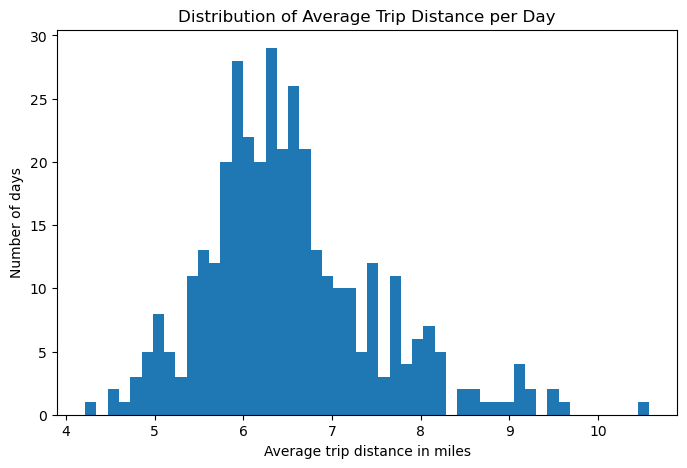

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(daily_metrics["average_trip_distance_miles"].dropna(), bins=50)
plt.title("Distribution of Average Trip Distance per Day")
plt.xlabel("Average trip distance in miles")
plt.ylabel("Number of days")
plt.show()

In [ ]:
df_idle = sample_data_df.copy()

df_idle["trip_start_timestamp"] = pd.to_datetime(df_idle["trip_start_timestamp"])
df_idle["trip_end_timestamp"] = pd.to_datetime(df_idle["trip_end_timestamp"])

df_idle = df_idle.sort_values(["taxi_id", "trip_start_timestamp"])

df_idle["next_trip_start"] = (
    df_idle
    .groupby("taxi_id")["trip_start_timestamp"]
    .shift(-1)
)

df_idle["idle_time_minutes"] = (
    df_idle["next_trip_start"] - df_idle["trip_end_timestamp"]
).dt.total_seconds() / 60

df_idle.loc[df_idle["idle_time_minutes"] < 0, "idle_time_minutes"] = pd.NA

In [ ]:
idle_time_metric = df_idle["idle_time_minutes"].mean()
idle_time_metric

np.float64(12847.382140647556)

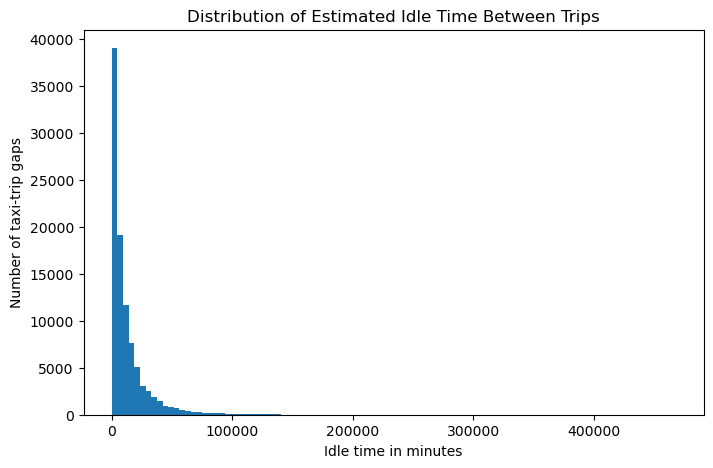

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df_idle["idle_time_minutes"].dropna(), bins=100)
plt.title("Distribution of Estimated Idle Time Between Trips")
plt.xlabel("Idle time in minutes")
plt.ylabel("Number of taxi-trip gaps")
plt.show()